#### 4.10 实战Kaggle比赛：预测房价
##### 4.10.1 下载和缓存数据集
简历字典```DATA_HUB```，将数据集名称的字符串映射到数据及相关的二元数组上，包含数据集的```url```和验证文件完整性的sha-1密钥，所有类似的数据集都托管在地址为DATA_HUB的站点上。

In [8]:
import hashlib
import os
import tarfile
import zipfile
import requests

#@save
DATA_HUB = dict()
DATA_URL = 'http://d2l-data.s3-accelerate.amazonaws.com/'

以下```download```函数用来下载数据集，下载数据集存放在本地目录，返回下载文件的名称。

In [9]:
def download(name, cache_dir=os.path.join('..', 'data')):   #@save
    """下载一个DATA_HUB中的文件，返回本地文件名"""
    assert name in DATA_HUB, f"{name} 不存在于 {DATA_HUB}"
    url, sha1_hash = DATA_HUB[name]
    os.makedirs(cache_dir, exist_ok=True)
    fname = os.path.join(cache_dir, url.split('/')[-1])
    if os.path.exists(fname):
        sha1 = hashlib.sha1()
        with open(fname, 'rb') as f:
            while True:
                data = f.read(1048576)
                if not data:
                    break
                sha1.update(data)
        if sha1.hexdigest() == sha1_hash:
            return fname    # 命中缓存
    print(f'正在从{url}下载{fname}...')
    r = requests.get(url, stream=True, verify=True)
    with open(fname, 'wb') as f:
        f.write(r.content)
    return fname

以下两个函数分别实现解压zip/tar文件，另一个使用的所有数据集从DATA_HUB下载到缓存目录中。

In [10]:
def download_extrac(name, folder=None): #@save
    """下载并解压缩zip/tar文件"""
    fname = download(name)
    base_dir = os.path.dirname(fname)
    data_dir, ext = os.path.aplitext(fname)
    if ext == '.zip':
        fp = zipfile.ZipFile(fname, 'r')
    elif ext in ('.tar', '.gz'):
        fp = tarfile.open(fname, 'r')
    else:
        assert False, '只有zip/tar文件可以被解压缩'
    fp.extractall(base_dir)
    return os.path.join(base_dir, folder) if folder else data_dir

def download_all(): #@save
    """下载DATA_HUB中的所有文件"""
    for name in DATA_HUB:
        download(name)

##### 4.10.2 Kaggle
##### 4.10.3 访问和读取数据集

In [11]:
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader
DATA_HUB['kaggle_house_train'] = (  #@save
    DATA_URL + 'kaggle_house_pred_train.csv',
    '585e9cc93e70b39160e7921475f9bcd7d31219ce')

DATA_HUB['kaggle_house_test'] = (  #@save
    DATA_URL + 'kaggle_house_pred_test.csv',
    'fa19780a7b011d9b009e8bff8e99922a8ee2eb90')
train_data = pd.read_csv(download('kaggle_house_train'))
test_data = pd.read_csv(download('kaggle_house_test'))
print(train_data.shape, test_data.shape)

(1460, 81) (1459, 80)


In [12]:
print(train_data.iloc[0:4, [0, 1, 2, 3, -3, -2, -1]])
all_features = pd.concat((train_data.iloc[:, 1:-1], test_data.iloc[:, 1:]))

   Id  MSSubClass MSZoning  LotFrontage SaleType SaleCondition  SalePrice
0   1          60       RL         65.0       WD        Normal     208500
1   2          20       RL         80.0       WD        Normal     181500
2   3          60       RL         68.0       WD        Normal     223500
3   4          70       RL         60.0       WD       Abnorml     140000


##### 4.10.4 数据预处理
首先将所有缺失值替换为相应特征的平均值，然后通过将特征重新缩放到零均值和单位方差来标准化数据，使得将所有特征放在一个共同的尺度上：
$$x\leftarrow\frac{x-\mu}{\sigma}，E[(x-\mu)]=0，E[(x-\mu)^2]=\sigma^2$$

In [13]:
# 只选真正的数值列
numeric_features = all_features.select_dtypes(include=['number']).columns

# 标准化
all_features[numeric_features] = all_features[numeric_features].apply(
    lambda x: (x - x.mean()) / x.std())

# 填充缺失值
all_features[numeric_features] = all_features[numeric_features].fillna(0)

处理离散值，使用热独编码替换之。

In [14]:
# ummy_na=Ture将NA视为有效的特征值，并为其创建指示符特征
all_features = pd.get_dummies(all_features, dummy_na=True)
all_features.shape

(2919, 330)

通过```values```属性，从pandas格式中提取NumPy格式并将其转换为张量表示用于训练。

In [15]:
n_train = train_data.shape[0]
train_features = np.array(all_features[:n_train].values, dtype=np.float32)
test_features = np.array(all_features[n_train:].values, dtype=np.float32)
train_labels = np.array(
    train_data.SalePrice.values.reshape(-1, 1), dtype=np.float32)
train_features = torch.from_numpy(train_features)
test_features = torch.from_numpy(test_features)
train_labels = torch.from_numpy(train_labels)

##### 4.10.5 训练
首先训练一个带有损失平方的线性模型，作为一种基线（Baseline）模型检查健全性。

In [61]:
loss = nn.MSELoss()
in_features = train_features.shape[1]
def get_net():
    net = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features, 128),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(128, 1)
    )
    return net

误差评价指标：
$$|\log y-\log\hat{y}\leq\Rightarrow e^{-\delta}\leq\hat{y}-y\leq e^{\delta}$$
得到：
$$l=\sqrt{\frac{1}{n}\sum_{i=1}^n(\log y_i-\log\hat{y})^2}$$

In [5]:
def log_rmse(net, features, labels):
    # 为了取对数保持稳定，将小于1的值设为1
    clipped_preds = torch.clamp(net(features), 1, float('inf'))
    rmse = torch.sqrt(loss(torch.log(clipped_preds), torch.log(labels)))
    return rmse

借助Adam优化器进行训练。

*补充*：随机梯度下降
$$x_{t+1}=x_t-\eta\cdot f'(x_t)$$

In [4]:
def train(net, train_features, train_labels, test_features, test_labels,
          num_epochs, learning_rate, weight_decay, batch_size):
    train_ls, test_ls = [], []
    # 构造数据集：将(features, labels)组成一个样本
    dataset = TensorDataset(train_features, train_labels)
    # 自动分batch，自动打乱，每次返回一小批数据
    train_iter = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    # 使用Adam优化器
    optimizer = torch.optim.Adam(net.parameters(),
                                 lr = learning_rate,
                                 weight_decay = weight_decay)
    for epoch in range(num_epochs):         # 遍历num_epochs次
        for X, y in train_iter:             # 每次获取一小批batch_size的数据
            optimizer.zero_grad()           # 梯度清零，取消累加
            l = loss(net(X), y)             # 前向传播，损失计算
            l.backward()                    # 反向传播，自动计算所有参数的梯度
            optimizer.step()                # 用梯度更新参数
        train_ls.append(log_rmse(net, train_features, train_labels).item())
        if test_labels is not None:
            test_ls.append(log_rmse(net, test_features, test_labels).item())
    return train_ls, test_ls

###### 4.10.6 K折交叉验证
K折交叉验证，有助于模型选择和超参数调整。定义一个函数，在K折交叉验证过程中返回第i折的数据：选择第i个切片作为验证数据，其余部分作为训练数据。

In [3]:
def get_k_fold_data(k, i, X, y):
    assert k > 1
    fold_size = X.shape[0] // k
    X_train, y_train = None, None
    for j in range(k):
        idx = slice(j * fold_size, (j + 1) * fold_size)
        X_part, y_part = X[idx, :], y[idx]
        if j == i:
            X_valid, y_valid = X_part, y_part
        elif X_train is None:
            X_train, y_train = X_part, y_part
        else:
            X_train = torch.cat([X_train, X_part], 0)
            y_train = torch.cat([y_train, y_part], 0)
    return X_train, y_train, X_valid, y_valid

训练K次后，返回训练和验证误差的平均值。

In [2]:
import matplotlib
from matplotlib import pyplot as plt
def k_fold(k, X_train, y_train, num_epochs, learning_rate, weight_decay, batch_size):
    train_l_sum, valid_l_sum = 0, 0
    for i in range(k):
        data = get_k_fold_data(k, i, X_train, y_train)
        net = get_net()
        train_ls, valid_ls = train(net, *data, num_epochs, learning_rate, weight_decay, batch_size)
        train_l_sum += train_ls[-1]
        valid_l_sum += valid_ls[-1]
        if i == 0:
            epochs = list(range(1, len(train_ls) + 1))
            plt.figure(figsize=(6, 4))
            plt.plot(epochs, train_ls, linestyle='-', label='train')
            plt.plot(epochs, valid_ls, linestyle='--', label='valid')
            plt.xlabel('epochs')
            plt.ylabel('log rmse')
            plt.legend()
            plt.grid(True)
            plt.tight_layout()
            plt.show()
        print(f'折{i + 1}，训练log rmse{float(train_ls[-1]):f}, '
              f'验证log rmse{float(valid_ls[-1]):f}')
    return train_l_sum / k, valid_l_sum / k

##### 4.10.7 模型选择
根据K折交叉验证，选择超参数。

对与超参数的选取，还有其他方法：
- 贝叶斯优化（Bayesian Optimization）：用一个“代理模型”去学习，根据已有结果，预测哪里可能更好，再作尝试；
- AutoML/神经架构搜索（NAS）：连网络一起优化；用强化学习/演化算法。

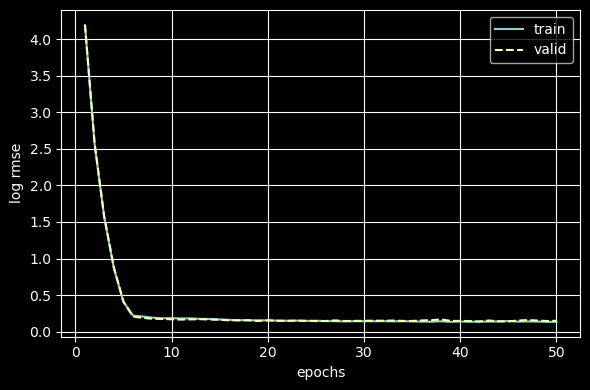

折1，训练log rmse0.134278, 验证log rmse0.149264
折2，训练log rmse0.135507, 验证log rmse0.155592
折3，训练log rmse0.130692, 验证log rmse0.149903
折4，训练log rmse0.138651, 验证log rmse0.135810
折5，训练log rmse0.133456, 验证log rmse0.169673
lr=0.05, weight_decay=0.1, batch_size=64
5-折验证：平均训练log rmse：0.134517, 平均验证log rmse0.152048


In [71]:
k, num_epochs, lr, weight_decay, batch_size = 5, 50, 0.05, 0.1, 64
train_l, valid_l = k_fold(k, train_features, train_labels, num_epochs, lr, weight_decay, batch_size)
print(f'lr={lr}, weight_decay={weight_decay}, batch_size={batch_size}')
print(f'{k}-折验证：平均训练log rmse：{float(train_l):f}, '
      f'平均验证log rmse{float(valid_l):f}')

##### 4.10.8 提交Kaggle预测

In [46]:
def train_and_pred(train_features, test_features, train_labels, test_data, num_epochs, lr, weight_decay, batch_size):
    net = get_net()
    # 训练模型
    train_ls, _ = train(net, train_features, train_labels, None, None, num_epochs, lr, weight_decay, batch_size)

    # 绘制训练曲线（可选）
    plt.plot(list(range(1, num_epochs + 1)), train_ls)
    plt.xlabel('epoch')
    plt.ylabel('rmse')
    plt.show()
    print(f'最终训练 log rmse：{float(train_ls[-1]):f}')

    # --- 下面是修改的核心部分 ---

    # 1. 获得预测值并转为 Numpy 数组
    # 使用 .detach().numpy() 将 Tensor 转为 Numpy，用 .reshape(-1) 转为一维
    preds = net(test_features).detach().numpy().reshape(-1)

    # 2. 构造只包含 Id 和 SalePrice 的 DataFrame
    # 确保 test_data['Id'] 存在且长度与 preds 一致
    submission = pd.DataFrame({
        'Id': test_data['Id'],
        'SalePrice': preds
    })

    # 3. 导出 CSV，记得去掉索引列
    submission.to_csv('submission.csv', index=False)
    print("预测完成，submission.csv 已生成。")

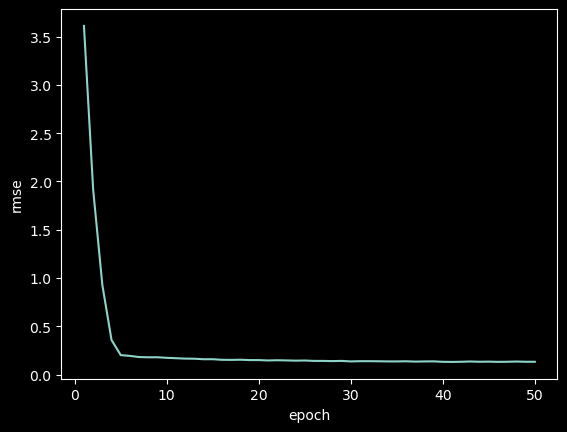

最终训练 log rmse：0.132754
预测完成，submission.csv 已生成。


In [72]:
train_and_pred(train_features, test_features, train_labels, test_data, num_epochs, lr, weight_decay, batch_size)